# Step 1: Import required libraries.

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from keras.preprocessing.text import Tokenizer
from keras.preprocessing import sequence
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Step 2: Read Train data (Descriptive and Exploratory analysis)

In [2]:
train_data=pd.read_csv('../input/nlp-getting-started/train.csv')

In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
train_data

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


## Visualizing the number of words in sentences


In [5]:
word_len=[]
for i in range(len(train_data)):
    word_len.append(len(train_data.text.values[i].split(' ')))    

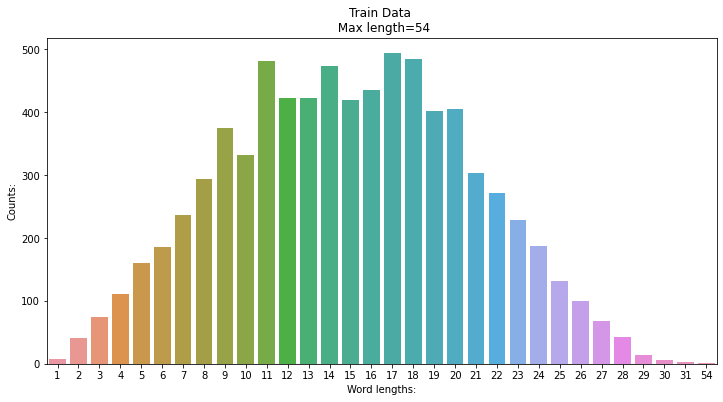

In [6]:
plt.figure(figsize=(12,6))
sns.countplot(word_len)
plt.xlabel("Word lengths:")
plt.ylabel('Counts:')
plt.title('Train Data \n Max length='+str(max(word_len)))
plt.show()

## Visualizing the number of instances in target field

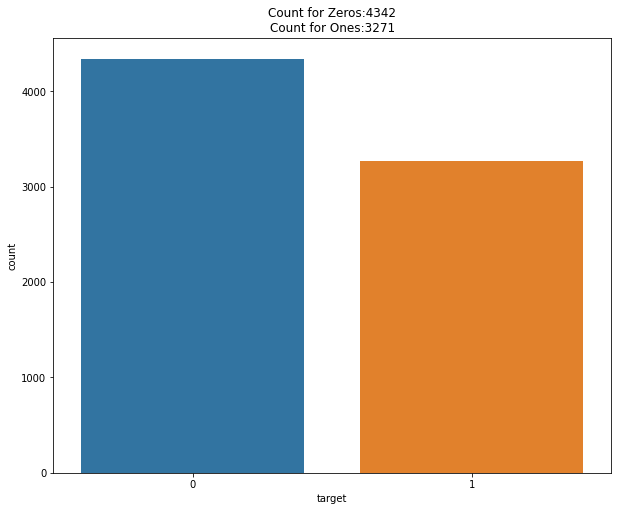

In [7]:
plt.figure(figsize=(10,8))
sns.countplot(train_data.target)
plt.title('Count for Zeros:'+str(train_data.target.value_counts()[0])+'\n'+
         'Count for Ones:'+str(train_data.target.value_counts()[1]))
plt.show()

# Step 3: Pre-processing

## As we can see there are 2 columns that contain null values (keyword and location), we will drop them since anyways we will only use the text and target columns

In [8]:
train_data=train_data.drop('keyword',axis=1)
train_data=train_data.drop('location',axis=1)

## Define X_train and Y_train data.

In [9]:
Y_train=train_data.target
X_train=train_data.text

## Reshaping Y_train so that it's easier to process it when using LSTM.

In [10]:
Y_train=tf.reshape(Y_train,(-1,1))

2021-10-21 06:30:35.817499: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-10-21 06:30:35.906762: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-10-21 06:30:35.907461: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2021-10-21 06:30:35.911376: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [11]:
Y_train

<tf.Tensor: shape=(7613, 1), dtype=int64, numpy=
array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]])>

## Tokenizing the train text data

In [12]:
max_words = 100000
max_len = 100

tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X_train)
sequences = tok.texts_to_sequences(X_train)
sequences_matrix = sequence.pad_sequences(sequences,maxlen=max_len)

In [13]:
sequences_matrix[1729]

array([    0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,     0,     0,     0,     0,     0,     0,
           0,     0,     0,  1385,  5458,  2023,   322,  2625,  1481,
        3265,    26,    34, 10531,     7,     4,  3881,  1094,    41,
          62,     8,    85, 10532,   342,    16,     3,     1,     2,
       10533], dtype=int32)

# Step 4: Creating RNN Model 

In [14]:
model=tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=[max_len]))
model.add(tf.keras.layers.Embedding(max_words,128,input_length=max_len))    

model.add(tf.keras.layers.LSTM(200, return_sequences=True))
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.LSTM(200,return_sequences=True))
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.LSTM(200))
model.add(tf.keras.layers.Dropout(0.5))
          
model.add(tf.keras.layers.Dense(256))
model.add(tf.keras.layers.Dropout(0.5))

model.add(tf.keras.layers.Dense(1,activation='sigmoid')) #output layer

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 100, 128)          12800000  
_________________________________________________________________
lstm (LSTM)                  (None, 100, 200)          263200    
_________________________________________________________________
dropout (Dropout)            (None, 100, 200)          0         
_________________________________________________________________
lstm_1 (LSTM)                (None, 100, 200)          320800    
_________________________________________________________________
dropout_1 (Dropout)          (None, 100, 200)          0         
_________________________________________________________________
lstm_2 (LSTM)                (None, 200)               320800    
_________________________________________________________________
dropout_2 (Dropout)          (None, 200)               0

In [16]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['acc'])

# Step 5: Training the model

In [17]:
hist=model.fit(sequences_matrix,Y_train,batch_size=64,epochs=30)

2021-10-21 06:30:40.131150: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/30


2021-10-21 06:30:44.705480: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


119/119 [==============================] - 9s 31ms/step - loss: 0.5274 - acc: 0.7397
Epoch 2/30
119/119 [==============================] - 4s 30ms/step - loss: 0.2883 - acc: 0.8883
Epoch 3/30
119/119 [==============================] - 4s 30ms/step - loss: 0.1461 - acc: 0.9485
Epoch 4/30
119/119 [==============================] - 4s 30ms/step - loss: 0.0770 - acc: 0.9750
Epoch 5/30
119/119 [==============================] - 4s 30ms/step - loss: 0.0443 - acc: 0.9879
Epoch 6/30
119/119 [==============================] - 4s 31ms/step - loss: 0.0291 - acc: 0.9916
Epoch 7/30
119/119 [==============================] - 4s 30ms/step - loss: 0.0245 - acc: 0.9921
Epoch 8/30
119/119 [==============================] - 4s 30ms/step - loss: 0.0200 - acc: 0.9933
Epoch 9/30
119/119 [==============================] - 4s 31ms/step - loss: 0.0155 - acc: 0.9933
Epoch 10/30
119/119 [==============================] - 4s 31ms/step - loss: 0.0242 - acc: 0.9926
Epoch 11/30
119/119 [=============================

# Step 6: Metrics and results

## Train Accuracy

In [18]:
model.evaluate(sequences_matrix,Y_train)

238/238 [==============================] - 3s 9ms/step - loss: 0.0058 - acc: 0.9967


[0.005796595476567745, 0.9967161417007446]

## Visualizing Train loss and accuracy epoch wise

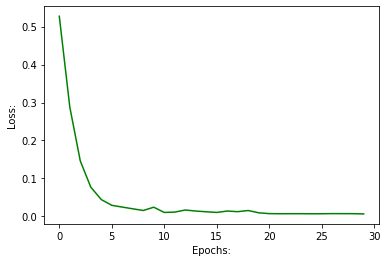

In [19]:
plt.plot(hist.history['loss'],'g')
plt.xlabel('Epochs:')
plt.ylabel('Loss:')
plt.show()

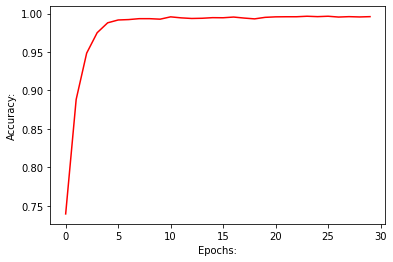

In [20]:
#accuracy

plt.plot(hist.history['acc'],'r')
plt.xlabel('Epochs:')
plt.ylabel('Accuracy:')
plt.show()

# Step 7: Prediction on test data

In [21]:
test_data=pd.read_csv('../input/nlp-getting-started/test.csv')

In [22]:
X_test=test_data.text

In [23]:
tok = Tokenizer(num_words=max_words)
tok.fit_on_texts(X_test)
sequences_test = tok.texts_to_sequences(X_test)
sequences_matrix_test = sequence.pad_sequences(sequences_test,maxlen=max_len)

## Predict

In [24]:
pred=model.predict(sequences_matrix_test)

## This step is required because i have used sigmoid activation function at the output layer. 

In [25]:
pred=(pred>0.5)*1

## Submission

In [26]:
p=pd.DataFrame()
p['id']=test_data['id']
p['target']=pred

In [27]:
p.to_csv('./Submission_sachin.csv',index=False)